# 深入例子一：Supervisor、子图与多 Agent 协作

> 本 Notebook 接续 `deep_agent_core_langchain_langgraph.ipynb` 和 `deep_agent_orchestration_workflows.ipynb`。
> 重点不是创建更多角色，而是理解 Supervisor 如何路由、子图如何隔离、结果如何通过明确契约回到父图。

所有节点使用确定性规则，离线即可运行。把规则节点替换成 LLM 时，仍然要保留路由白名单和 State 契约。

## 学习目标

1. 区分父图状态和子 Agent 状态。
2. 用一个 Supervisor 把请求路由到专用子图。
3. 用显式输入/输出映射控制 handoff，而不是共享一个巨大的字典。
4. 为未知意图保留澄清路径，并为每次委派留下可审计轨迹。

In [1]:
from __future__ import annotations

import operator
from typing import Annotated, Literal, TypedDict

from IPython.display import Image, display
from langgraph.graph import END, START, StateGraph


def show_graph(graph) -> None:
    display(Image(graph.get_graph().draw_mermaid_png()))


print('环境准备完成：本例不调用真实模型。')

环境准备完成：本例不调用真实模型。


## 1. 先写两个隔离的子图

研究 Agent 只关心资料和摘要；代码 Agent 只关心问题类型和修复建议。它们不应该直接读写 Supervisor 的所有字段。

子图的边界就是 Agent 的边界：输入最小化，输出结构化。

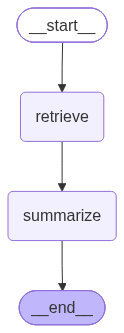

In [2]:
class ResearchState(TypedDict, total=False):
    question: str
    evidence: Annotated[list[str], operator.add]
    summary: str
    trace: Annotated[list[str], operator.add]


def research_retrieve(state: ResearchState):
    return {
        'evidence': [
            'StateGraph 用节点和边组织有状态流程。',
            'Reducer 决定并行节点如何合并列表字段。',
        ],
        'trace': ['research.retrieve'],
    }


def research_summarize(state: ResearchState):
    return {
        'summary': f"研究结论：{state['question']}；关键点是：{'；'.join(state['evidence'])}",
        'trace': ['research.summarize'],
    }


research_builder = StateGraph(ResearchState)
research_builder.add_node('retrieve', research_retrieve)
research_builder.add_node('summarize', research_summarize)
research_builder.add_edge(START, 'retrieve')
research_builder.add_edge('retrieve', 'summarize')
research_builder.add_edge('summarize', END)
research_agent = research_builder.compile()
show_graph(research_agent)

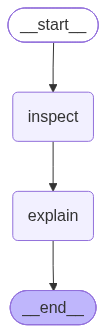

In [3]:
class CodeState(TypedDict, total=False):
    question: str
    diagnosis: str
    fix: str
    trace: Annotated[list[str], operator.add]


def inspect_code_problem(state: CodeState):
    return {
        'diagnosis': '先确认 State 字段、节点返回值和条件边标签是否一致。',
        'trace': ['code.inspect'],
    }


def explain_code_fix(state: CodeState):
    return {
        'fix': f"修复建议：针对“{state['question']}”，先写一个最小断言，再运行单个图分支。",
        'trace': ['code.explain'],
    }


code_builder = StateGraph(CodeState)
code_builder.add_node('inspect', inspect_code_problem)
code_builder.add_node('explain', explain_code_fix)
code_builder.add_edge(START, 'inspect')
code_builder.add_edge('inspect', 'explain')
code_builder.add_edge('explain', END)
code_agent = code_builder.compile()
show_graph(code_agent)

## 2. 构建 Supervisor 父图

Supervisor 只做三件事：分类、委派、汇总。

真实项目中，`classify_request` 可以换成结构化 LLM；但它只能返回白名单里的 `research`、`code` 或 `clarify`。子图调用封装在 `run_*` 节点中，父图不会暴露子图的内部 State。

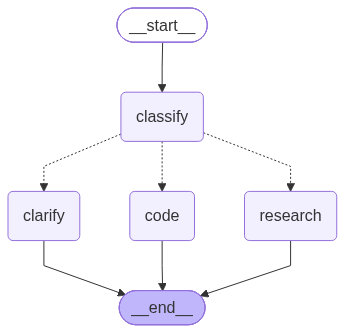

In [4]:
class SupervisorState(TypedDict, total=False):
    question: str
    route: Literal['research', 'code', 'clarify']
    answer: str
    evidence: Annotated[list[str], operator.add]
    trace: Annotated[list[str], operator.add]


def classify_request(state: SupervisorState):
    question = state['question']
    if any(word in question for word in ['资料', '研究', '原理', '是什么']):
        route = 'research'
    elif any(word in question for word in ['报错', '代码', '修复', '调试']):
        route = 'code'
    else:
        route = 'clarify'
    return {'route': route, 'trace': [f'supervisor.route:{route}']}


def choose_route(state: SupervisorState) -> Literal['research', 'code', 'clarify']:
    return state['route']


def run_research_agent(state: SupervisorState):
    child = research_agent.invoke({
        'question': state['question'],
        'evidence': [],
        'summary': '',
        'trace': [],
    })
    return {
        'answer': child['summary'],
        'evidence': child['evidence'],
        'trace': child['trace'] + ['supervisor.handoff:research'],
    }


def run_code_agent(state: SupervisorState):
    child = code_agent.invoke({
        'question': state['question'],
        'diagnosis': '',
        'fix': '',
        'trace': [],
    })
    return {
        'answer': f"{child['diagnosis']} {child['fix']}",
        'trace': child['trace'] + ['supervisor.handoff:code'],
    }


def clarify_request(_: SupervisorState):
    return {
        'answer': '请说明你要研究一个概念，还是排查一段代码。',
        'trace': ['supervisor.clarify'],
    }


supervisor_builder = StateGraph(SupervisorState)
supervisor_builder.add_node('classify', classify_request)
supervisor_builder.add_node('research', run_research_agent)
supervisor_builder.add_node('code', run_code_agent)
supervisor_builder.add_node('clarify', clarify_request)
supervisor_builder.add_edge(START, 'classify')
supervisor_builder.add_conditional_edges('classify', choose_route)
supervisor_builder.add_edge('research', END)
supervisor_builder.add_edge('code', END)
supervisor_builder.add_edge('clarify', END)
supervisor_graph = supervisor_builder.compile()
show_graph(supervisor_graph)

In [5]:
cases = [
    ('研究 LangGraph 的状态机制', 'research'),
    ('代码报错怎么调试', 'code'),
    ('帮我安排一个时间', 'clarify'),
]

for question, expected_route in cases:
    result = supervisor_graph.invoke({
        'question': question,
        'evidence': [],
        'trace': [],
    })
    print(question, '=>', result['route'], result['answer'])
    assert result['route'] == expected_route
    assert result['trace']

print('Supervisor 路由、子图 handoff 和澄清路径检查通过。')

研究 LangGraph 的状态机制 => research 研究结论：研究 LangGraph 的状态机制；关键点是：StateGraph 用节点和边组织有状态流程。；Reducer 决定并行节点如何合并列表字段。
代码报错怎么调试 => code 先确认 State 字段、节点返回值和条件边标签是否一致。 修复建议：针对“代码报错怎么调试”，先写一个最小断言，再运行单个图分支。
帮我安排一个时间 => clarify 请说明你要研究一个概念，还是排查一段代码。
Supervisor 路由、子图 handoff 和澄清路径检查通过。


## 3. 关键边界

- Supervisor 不直接执行研究或代码任务。
- 子 Agent 不负责改变父图路由。
- handoff 只传递完成任务所需的字段。
- 未知意图必须有终点，不能让模型自由猜测。
- `trace` 是审计信息，`answer` 是业务结果，两者不要混在一段自然语言里。

当子 Agent 需要真正调用模型时，建议让它返回 Pydantic 结果，再由父图决定是否接受。模型可以提出路由建议，但最终路由仍由代码白名单控制。

## 4. 练习

1. 增加一个 `billing` 子图，只处理发票和退款问题。
2. 给 Supervisor 增加 `confidence`，低于 0.8 时统一进入 `clarify`。
3. 让研究子图并行产生两个证据，再用 reducer 合并。
4. 把 `run_research_agent` 改成返回 `sources`，并在父图里拒绝没有来源的答案。
5. 给每个子图增加最大步数，观察为什么预算应该属于控制状态。